In [1]:
import sys
import os

# Get the project root (one directory above the notebook location)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

from utils import *

In [2]:
# After running CT3 and getting 'summary'
root = "C:/Users/JanderM/OneDrive - University of Twente/Documents/Github Repos/WP3_eXplainable_and_Fair_AI/IRP1/Code/ct3/code/results/20251119-114140/PredictionTask/ContextualUCBBanditAgent/LinearTrend"

# Example: plot directional accuracy vs μ
metrics =  load_ct3_metrics(root)
metrics

{'D_ham': {-0.5: [0.966, 0.953, 0.953, 0.953, 0.953, 0.953, 0.953, 0.953],
  -0.25: [0.958, 0.971, 0.971, 0.971, 0.971, 0.971, 0.971, 0.971],
  0.0: [0.007, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02],
  0.25: [0.0, 0.013, 0.013, 0.013, 0.013, 0.013, 0.013, 0.013],
  0.5: [0.012, 0.002, 0.002, 0.0, 0.0, 0.0, 0.001, 0.001]},
 'delta_p': {-0.5: [0.966, 0.953, 0.953, 0.953, 0.953, 0.953, 0.953, 0.953],
  -0.25: [0.958, 0.945, 0.945, 0.945, 0.945, 0.945, 0.945, 0.945],
  0.0: [0.007,
   -0.005999999999999999,
   -0.005999999999999999,
   -0.005999999999999999,
   -0.005999999999999999,
   -0.005999999999999999,
   -0.005999999999999999,
   -0.005999999999999999],
  0.25: [0.0, -0.013, -0.013, -0.013, -0.013, -0.013, -0.013, -0.013],
  0.5: [0.012,
   -0.002,
   -0.002,
   0.0,
   0.0,
   0.0,
   -0.0009999999999999992,
   -0.0009999999999999992]},
 'p_up': {-0.5: [0.966, 0.966, 0.966, 0.966, 0.966, 0.966, 0.966, 0.966],
  -0.25: [0.958, 0.958, 0.958, 0.958, 0.958, 0.958, 0.958, 0.958],
  0.0

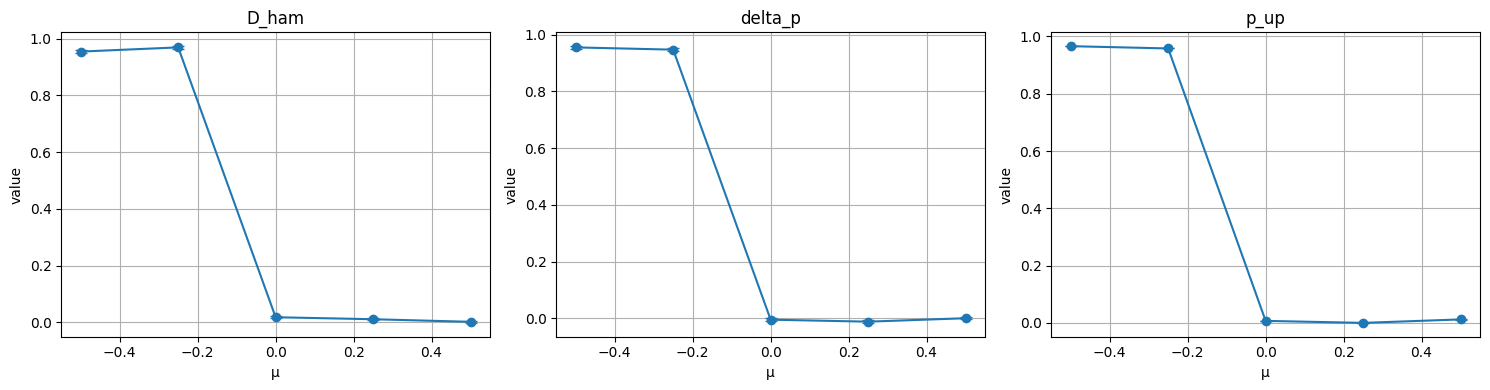

In [3]:
# --- Plot ---
num_metrics = len(metrics)
fig, axes = plt.subplots(1, num_metrics, figsize=(5 * num_metrics, 4), squeeze=False)
axes = axes[0]

for ax, (metric, mu_dict) in zip(axes, metrics.items()):
    mus = np.array(sorted(mu_dict.keys()))
    means = np.array([np.mean(mu_dict[mu]) for mu in mus])
    stds = np.array([np.std(mu_dict[mu]) for mu in mus])
    
    ax.errorbar(mus, means, yerr=stds, fmt='-o', capsize=4)
    ax.set_title(metric)
    ax.set_xlabel("μ")
    ax.set_ylabel("value")
    ax.grid(True)

plt.tight_layout()
plt.show()

From the plots above we can see that the policy changes behavior when the sign of the drift parameter flips. We also see that for positive drift the probability of up is almost zero and flips to almost one for negative drift. This is the opposite of ideal behavior.

The Divergence and Response metric seem to capture sensitivity to parameter changes but the direction is inverted.

Based on this we infer that the policy flips actions from down to up when going from positive to negative drift, leading to negative cumulative reward for each parameter setting.

In [4]:
train_log = load_training_log(root)

print(len(train_log),train_log[:3])

1000 [{'t': 1, 'value_prev': 0.0, 'value': 10.972963056006243, 'bet': 0, 'received_reward': -1, 'reward_cum': -1}, {'t': 2, 'value_prev': 10.972963056006243, 'value': 10.152076922294377, 'bet': 0, 'received_reward': 1, 'reward_cum': 0}, {'t': 3, 'value_prev': 10.152076922294377, 'value': 9.711359981295855, 'bet': 0, 'received_reward': 1, 'reward_cum': 1}]


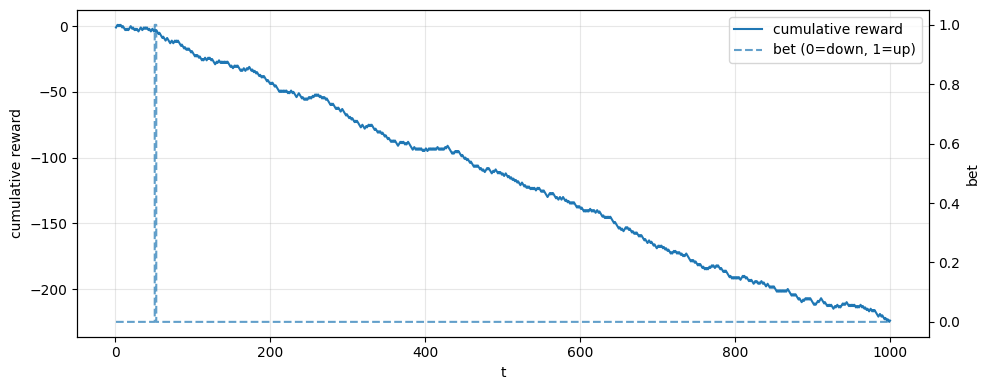

In [5]:

plot_reward_and_bets(train_log)


We can see that the agent already performed poorly during training, while only having one case of choosing "up". This could be due to the default action during warm-up phase to be "down" until there are sufficient observations in meory. Could also be something else.

In [6]:
root = "../results/20251119-114140/PredictionTask/ContextualUCBBanditAgent/LinearTrend"
mu = -0.5

logs = load_task_logs_for_mu(root, mu)

for k, log in logs.items():
    print("k=", k, "entries:", len(log))


k= 0 entries: 1000
k= 1 entries: 1000
k= 2 entries: 1000
k= 3 entries: 1000
k= 4 entries: 1000
k= 5 entries: 1000
k= 6 entries: 1000
k= 7 entries: 1000


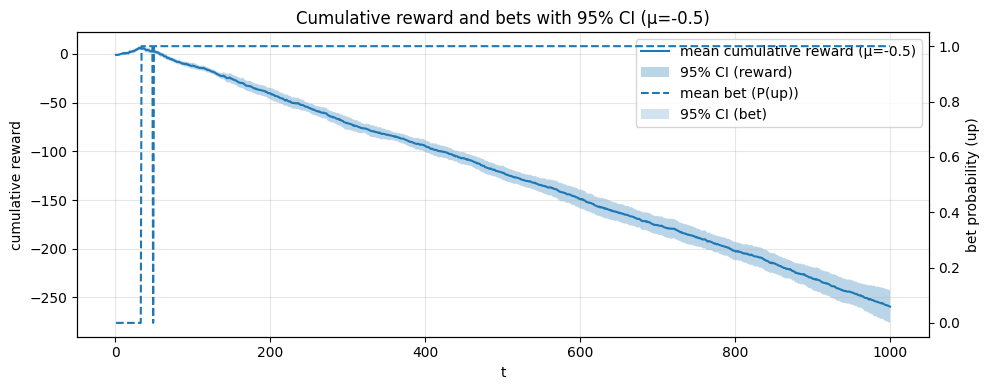

In [7]:
plot_reward_and_bets_with_ci_from_logs(logs, mu=-0.5)


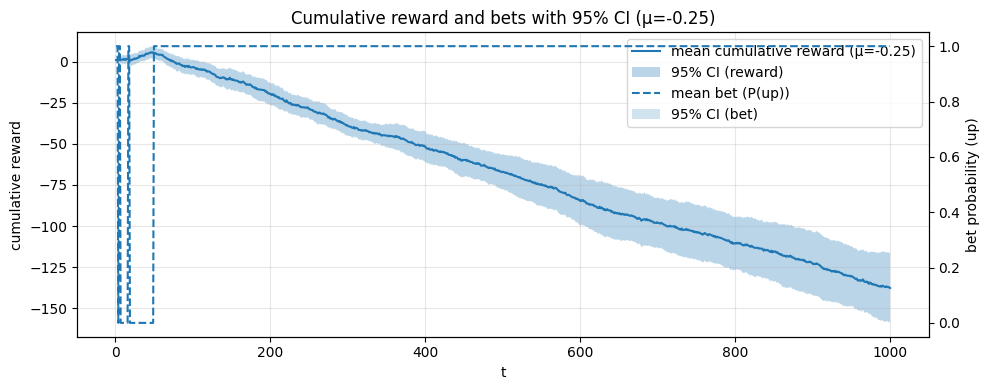

In [8]:
logs_by_k = load_task_logs_for_mu(root, mu=-0.25)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=-0.25)

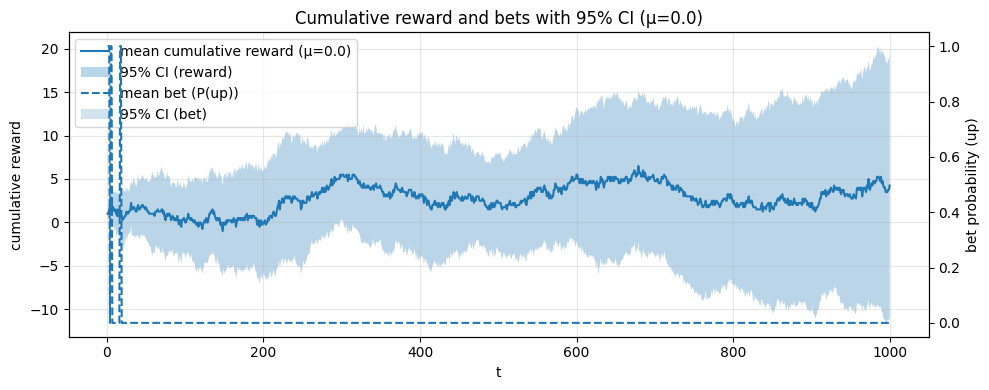

In [9]:
logs_by_k = load_task_logs_for_mu(root, mu=0.0)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.0)

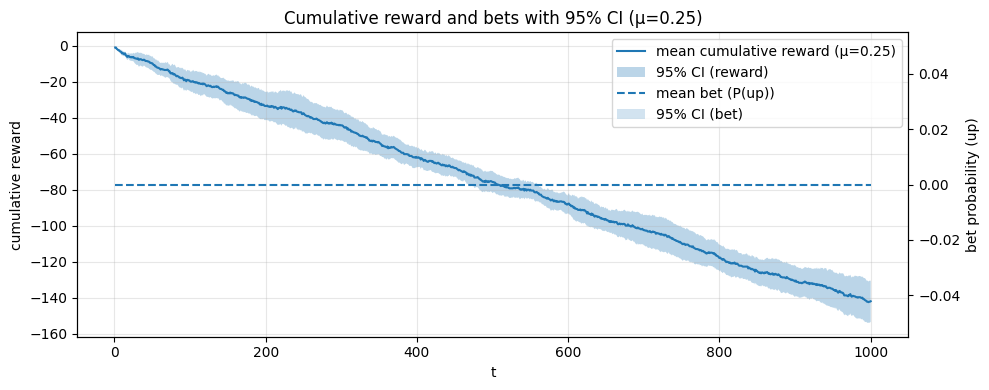

In [10]:
logs_by_k = load_task_logs_for_mu(root, mu=0.25)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.25)

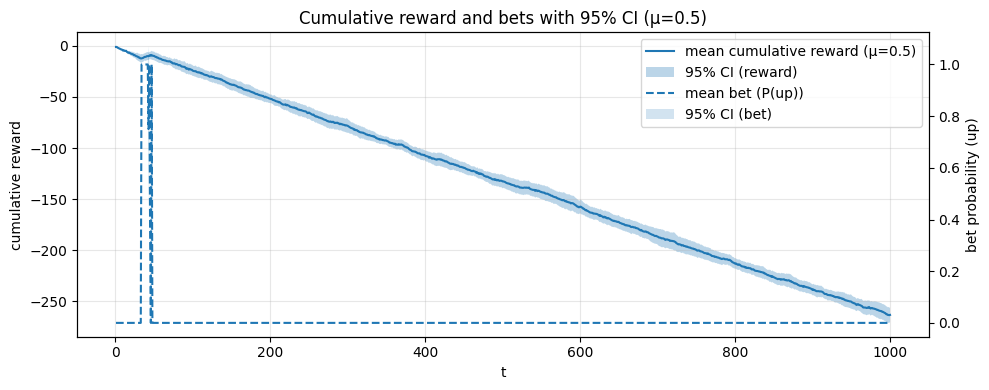

In [11]:
logs_by_k = load_task_logs_for_mu(root, mu=0.5)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.5)

Based on the cumulative reward and bets (actions) across counterfactual trajectories, we can confirm our inference that the policy bets mostly "up" for negative drift values and vice versa.

The agent seems to have  learned a policy that is sensitive to the change in the drift parameter with the wrong sign of direction.